In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('../plots/paper.mplstyle')
import cartopy.crs as ccrs
import matplotlib as mpl
import ensemble_lib as el

bezpyDataPath = '/glade/u/home/cobrien/ensemble-analysis/data/bezpy-data'

#Color and style
c1 = '#E76F51'
c2 = '#F4A261'
c3 = '#E9C46A'
c4 = '#2A9D8F'
c5 = '#264653'
r = '#BB3E03'
g = '#AE2012'
b = '#005F73'

/glade/work/cobrien/conda-envs/kaiju-3.12/lib/python3.12/site-packages/bezpy/mt/io.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
prime_mean_ds, prime_mean_metadata = el.generate_gic(
    mageDataPath = '/glade/derecho/scratch/cobrien/doctor-patient-day-prime',
    mageRunID = 'dptd-prime',
    bezpyDataPath = bezpyDataPath,
    )
prime_high_ds, prime_high_metadata = el.generate_gic(
    mageDataPath = '/glade/derecho/scratch/cobrien/doctor-patient-day-prime-high',
    mageRunID = 'dptd-prime-high',
    bezpyDataPath = bezpyDataPath,
    )
prime_low_ds, prime_low_metadata = el.generate_gic(
    mageDataPath = '/glade/derecho/scratch/cobrien/doctor-patient-day-prime-low',
    mageRunID = 'dptd-prime-low',
    bezpyDataPath = bezpyDataPath,
    )

/glade/work/cobrien/conda-envs/kaiju-3.12/lib/python3.12/pickle.py:1760: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  setstate(state)
/glade/work/cobrien/conda-envs/kaiju-3.12/lib/python3.12/pickle.py:1760: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  setstate(state)
/glade/work/cobrien/conda-envs/kaiju-3.12/lib/python3.12/pickle.py:1760: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  setstate(state)


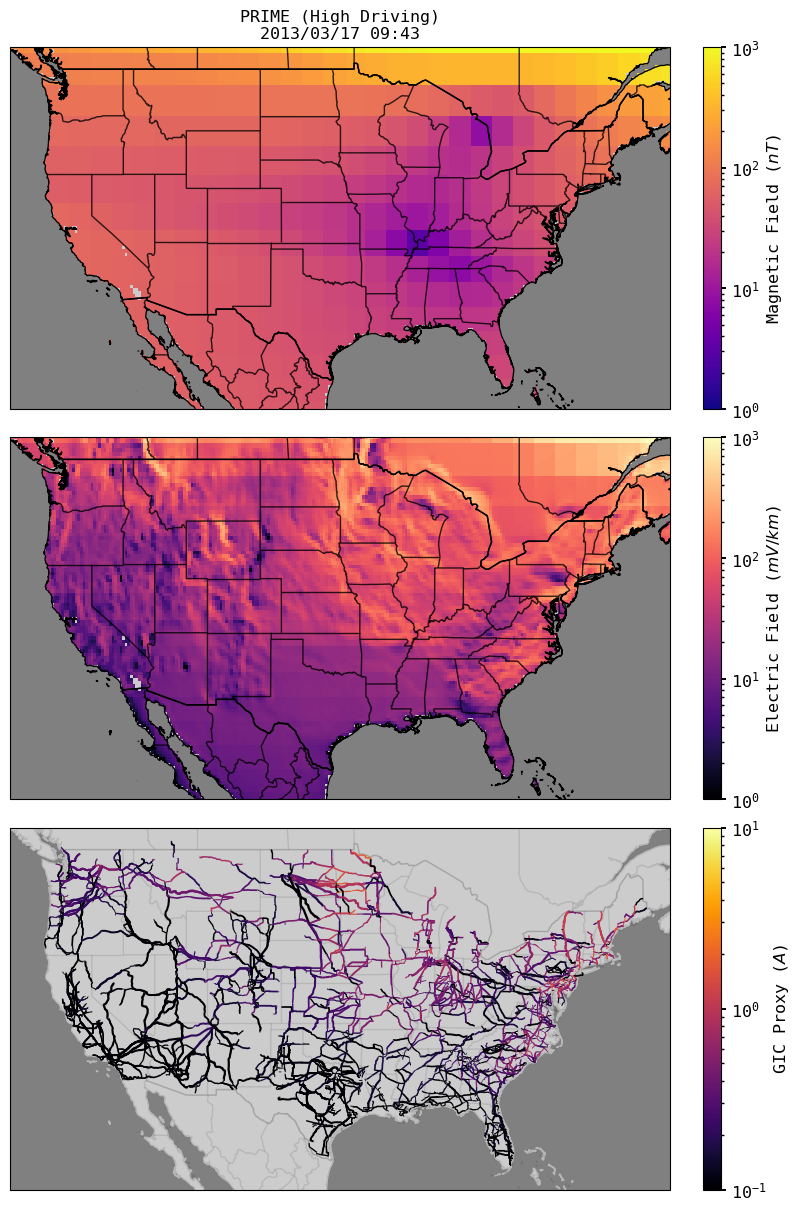

In [ ]:
feature_dict = el.prep_plot_objects() #Intializes countries, oceans, state borders, etc.
# Create the plot bounds
bbox = (np.min(prime_high_metadata['site_xys'][:, 0]), np.max(prime_high_metadata['site_xys'][:, 0]),
        np.min(prime_high_metadata['site_xys'][:, 1]), np.max(prime_high_metadata['site_xys'][:, 1]))
# Get the impedance grid
grid = el.init_grid(prime_high_metadata['site_xys'])

projection = ccrs.Mercator() #Plot projection style
fig, (ax_Bfield, ax_Efield, ax_gic) = plt.subplots(figsize=(8, 12), nrows=3, constrained_layout=True, subplot_kw=dict(projection=projection))

el.setup_axes(ax_Bfield, feature_dict=feature_dict, bbox = bbox, oceancolor = 'gray')
el.setup_axes(ax_Efield, feature_dict=feature_dict, bbox = bbox, oceancolor = 'gray')
el.setup_axes(ax_gic, feature_dict=feature_dict, bbox = bbox, oceancolor = 'gray', statealpha=0.1, countryalpha=0.1)

t = 583
model_name = "PRIME (High Driving)"
times = prime_high_ds["time"].dt.strftime('%Y/%m/%d %H:%M').values
title = ax_Bfield.set_title(f"{model_name}\n{times[t]}")

B_mesh = el.plot_quantity(ax_Bfield, prime_high_ds, prime_high_metadata['transmission_df'],
                          grid, t = t, quantity = "B",
                          B_norm = mpl.colors.LogNorm(1e0, 1e3), alpha = 1,
                          B_cmap = mpl.colormaps["plasma"],)
E_mesh = el.plot_quantity(ax_Efield, prime_high_ds, prime_high_metadata['transmission_df'],
                          grid, t = t, quantity = "E",
                          E_norm = mpl.colors.LogNorm(1e0, 1e3), alpha = 1,
                          E_cmap = mpl.colormaps["magma"])
I_coll = el.plot_quantity(ax_gic, prime_high_ds, prime_high_metadata['transmission_df'],
                          grid, t = t, quantity = "I",
                          I_norm = mpl.colors.LogNorm(1e-1, 1e1),
                          I_cmap = mpl.colormaps["inferno"]) # _coll for collection

# line_num = 6487
# ex_position = prime_high_metadata['transmission_df']['geometry'].iloc[line_num].coords[0]
# ax_gic.scatter(ex_position[0], ex_position[1], color = 'r', transform = ccrs.PlateCarree())

cbar = fig.colorbar(ax=ax_Bfield, mappable=B_mesh, orientation='vertical')
cbar.set_label('Magnetic Field ($nT$)')

cbar = fig.colorbar(ax=ax_Efield, mappable=E_mesh, orientation='vertical')
cbar.set_label('Electric Field ($mV/km$)')

cbar = fig.colorbar(ax=ax_gic, mappable=I_coll, orientation='vertical')
cbar.set_label('GIC Proxy ($A$)')

fig.canvas.draw()
fig.canvas.draw()
fig.set_constrained_layout(False)
# plt.savefig('plots/GIC_high_example.png', dpi = 300)

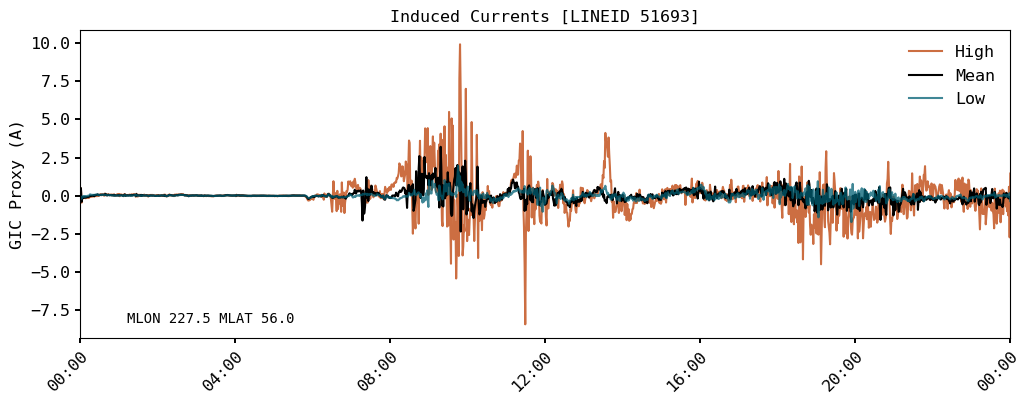

In [9]:
line_num = 6487 # iloc of transmission line in transmission_df metadata (from line dimension of gic dataset)
t_idx = int(9*60 + 48)

fig, ax = plt.subplots(1, 1, figsize = (12, 4))

plt.plot(prime_high_ds['I'].time, prime_high_ds['I'][:, line_num], label = 'High', color = r, alpha = 0.75)
plt.plot(prime_high_ds['I'].time, prime_mean_ds['I'][:, line_num], label = 'Mean', color = 'k', alpha = 1)
plt.plot(prime_high_ds['I'].time, prime_low_ds['I'][:, line_num],  label = 'Low',  color = b, alpha = 0.75)
plt.legend()

plt.ylabel("GIC Proxy (A)")
plt.title(f"Induced Currents [LINEID {prime_high_metadata['transmission_df'].iloc[line_num]['OBJECTID']}]")

# Load the position of the particular line to display MLON and MLAT
ex_position = prime_high_metadata['transmission_df']['geometry'].iloc[line_num].coords[0] # Position of first entry in powerline location
import h5py # For reading the file
lon_idx, lat_idx = el.lonlat_tf(ex_position[0], ex_position[1]) # Transform desired geo lon/lat to indices to pull mlon/mlat out of the file
f = h5py.File("/glade/derecho/scratch/cobrien/doctor-patient-day-prime-high/dptd-prime-high.deltab_lowres.h5", "r")
plt.text(0.05, 0.05, 
         s = f"MLON {f[f'Step#{t_idx}']['smlon'][0, lon_idx, lat_idx]:.1f} MLAT {f[f'Step#{t_idx}']['smlat'][0, lon_idx, lat_idx]:.1f}",
         transform = plt.gca().transAxes)

n_ticks = 7
# ticks = pd.date_range(start = '2013-03-17 04:00:00+0000', end = '2013-03-17 10:00:00+0000', periods = n_ticks)
ticks = pd.date_range(start = '2013-03-17 00:00:00+0000', end = '2013-03-18 00:00:00+0000', periods = n_ticks)
plt.xlim(ticks[0], ticks[-1])
_ = plt.xticks(ticks, labels = ticks.strftime('%H:%M'), rotation=45, ha = "right", rotation_mode='anchor')
# plt.savefig('plots/GIC_station.pdf', bbox_inches = 'tight')